# ROI Mask-UNet → KapoorLabs-StarDist vs Keras — distribution comparison

Loads the CSV written by `compare-roi-stardist-vs-keras.py` (the ROI-gated variant of the StarDist comparison) and renders one box plot per observable (nuclei count, mean / total volume, mean radius, mean / total surface area) summarising the distribution **across all timepoints**, stratified by developmental stage (early / mid / late). Two boxes per stage — orange = ROI → KapoorLabs-StarDist, blue = Keras. Box = IQR, whiskers = 1.5·IQR, line = median, ▲ = mean. Individual per-timepoint points overlaid as jittered scatter so outliers stay visible.

ROI gating crops each frame to the Mask-UNet bounding box before percentile normalisation + StarDist prediction — the early-embryo frames (mostly-empty volume) should now stay tighter against keras instead of inflating variance.

The script writes `<input_stem>.compare_roi.csv` into `compare_data_paths.out_dir`. Edit `CSV_PATH` below to point at it.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
CSV_PATH = Path("/mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare_roi.csv")

# Where to save the box-plot figure. Default = next to the notebook.
# Run the notebook from ``scripts/model_prediction/`` (Jupyter's CWD =
# the notebook dir) for the default to land there; otherwise edit the
# path to an absolute location.
OUT_PNG = Path("compare_roi_stardist_vs_keras.png")

# Optional voxel-spacing for physical-unit plots. Leave at 1.0 for
# voxel-space numbers (default — matches the script).
VOXEL_VOLUME_UM3 = 1.0   # multiply ``*_volume_vox`` by this to get µm³
VOXEL_LENGTH_UM = 1.0    # multiply ``mean_radius_vox`` by this to get µm
VOXEL_AREA_UM2 = 1.0     # multiply ``*_surface_area`` by this to get µm²

# Box-chart colours.
COLOR_STARDIST = '#d4773a'
COLOR_KERAS = '#3a7ca5'

In [9]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"{CSV_PATH} not found — run compare-roi-stardist-vs-keras.py first"
    )
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Sources: {df['source'].unique().tolist()}")
print(f"T-indices: {sorted(df['t_index'].unique().tolist())}")
df.head()

Loaded 30 rows from /mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare_roi.csv
Sources: ['stardist', 'keras']
T-indices: [0, 1, 2, 3, 4, 93, 94, 95, 96, 97, 187, 188, 189, 190, 191]


,t_index,source,n_nuclei,mean_volume_vox,total_volume_vox,mean_radius_vox,mean_surface_area,total_surface_area
0,0,stardist,348,1293.175287,450025.0,6.616178,710.329197,247194.560638
1,0,keras,366,1285.986339,470671.0,6.639450,699.176312,255898.530060
2,1,stardist,356,1294.275281,460762.0,6.615485,709.763272,252675.724731
3,1,keras,377,1274.326260,480421.0,6.612595,693.607592,261490.062012
4,2,stardist,367,1378.261580,505822.0,6.749037,734.591855,269595.210754


In [10]:
# Pivot to wide form so each metric is a pair of columns (one per source).
metric_cols = [c for c in df.columns if c not in ('t_index', 'source')]
wide = df.pivot(index='t_index', columns='source', values=metric_cols).sort_index()
wide.columns = [f'{m}__{s}' for m, s in wide.columns]
wide.reset_index(inplace=True)
wide

,t_index,n_nuclei__keras,n_nuclei__stardist,mean_volume_vox__keras,mean_volume_vox__stardist,total_volume_vox__keras,total_volume_vox__stardist,mean_radius_vox__keras,mean_radius_vox__stardist,mean_surface_area__keras,mean_surface_area__stardist,total_surface_area__keras,total_surface_area__stardist
0,0,366.0,348.0,1285.986339,1293.175287,470671.0,450025.0,6.639450,6.616178,699.176312,710.329197,2.558985e+05,2.471946e+05
1,1,377.0,356.0,1274.326260,1294.275281,480421.0,460762.0,6.612595,6.615485,693.607592,709.763272,2.614901e+05,2.526757e+05
2,2,383.0,367.0,1298.412533,1378.261580,497292.0,505822.0,6.648163,6.749037,700.481618,734.591855,2.682845e+05,2.695952e+05
3,3,384.0,378.0,1318.661458,1301.931217,506366.0,492130.0,6.694118,6.617310,707.685703,705.125169,2.717513e+05,2.665373e+05
4,4,390.0,387.0,1313.015385,1319.441860,512076.0,510624.0,6.688552,6.659847,707.415453,716.467900,2.758920e+05,2.772731e+05
5,93,1325.0,1275.0,1246.796981,1207.356863,1652006.0,1539380.0,6.565246,6.480737,703.077921,692.259006,9.315782e+05,8.826302e+05
6,94,1336.0,1275.0,1243.196108,1214.064314,1660910.0,1547932.0,6.559042,6.501459,702.216128,696.107036,9.381607e+05,8.875365e+05
7,95,1360.0,1300.0,1231.869118,1204.675385,1675342.0,1566078.0,6.534699,6.477988,697.278258,691.948128,9.482984e+05,8.995326e+05
8,96,1371.0,1305.0,1236.270605,1204.391571,1694927.0,1571731.0,6.546025,6.478212,699.867567,691.257074,9.595184e+05,9.020905e+05
9,97,1394.0,1324.0,1235.309182,1148.636707,1722021.0,1520795.0,6.540588,6.372240,699.725255,671.944050,9.754170e+05,8.896539e+05


In [11]:
# Per-metric mean across timepoints — a single-number sanity table.
rows = []
for m in metric_cols:
    sd = wide.get(f'{m}__stardist')
    kr = wide.get(f'{m}__keras')
    if sd is None or kr is None:
        continue
    rows.append({
        'metric': m,
        'stardist_mean': float(sd.mean()),
        'keras_mean': float(kr.mean()),
        'ratio_sd_over_keras': float(sd.mean() / kr.mean()) if kr.mean() else float('nan'),
    })
pd.DataFrame(rows)

,metric,stardist_mean,keras_mean,ratio_sd_over_keras
0,n_nuclei,1.439933e+03,1.476400e+03,0.975300
1,mean_volume_vox,1.182471e+03,1.210204e+03,0.977084
2,total_volume_vox,1.593544e+06,1.706339e+06,0.933897
3,mean_radius_vox,6.417558e+00,6.496257e+00,0.987886
4,mean_surface_area,6.845630e+02,6.929984e+02,0.987828
5,total_surface_area,9.603811e+05,1.013145e+06,0.947920


Stage T-indices: early=[0, 1, 2, 3, 4], mid=[93, 94, 95, 96, 97], late=[187, 188, 189, 190, 191]


Saved /mnt/disk/python_workspace/KapoorLabs-VollSeg/scripts/model_prediction/compare_roi_stardist_vs_keras.png


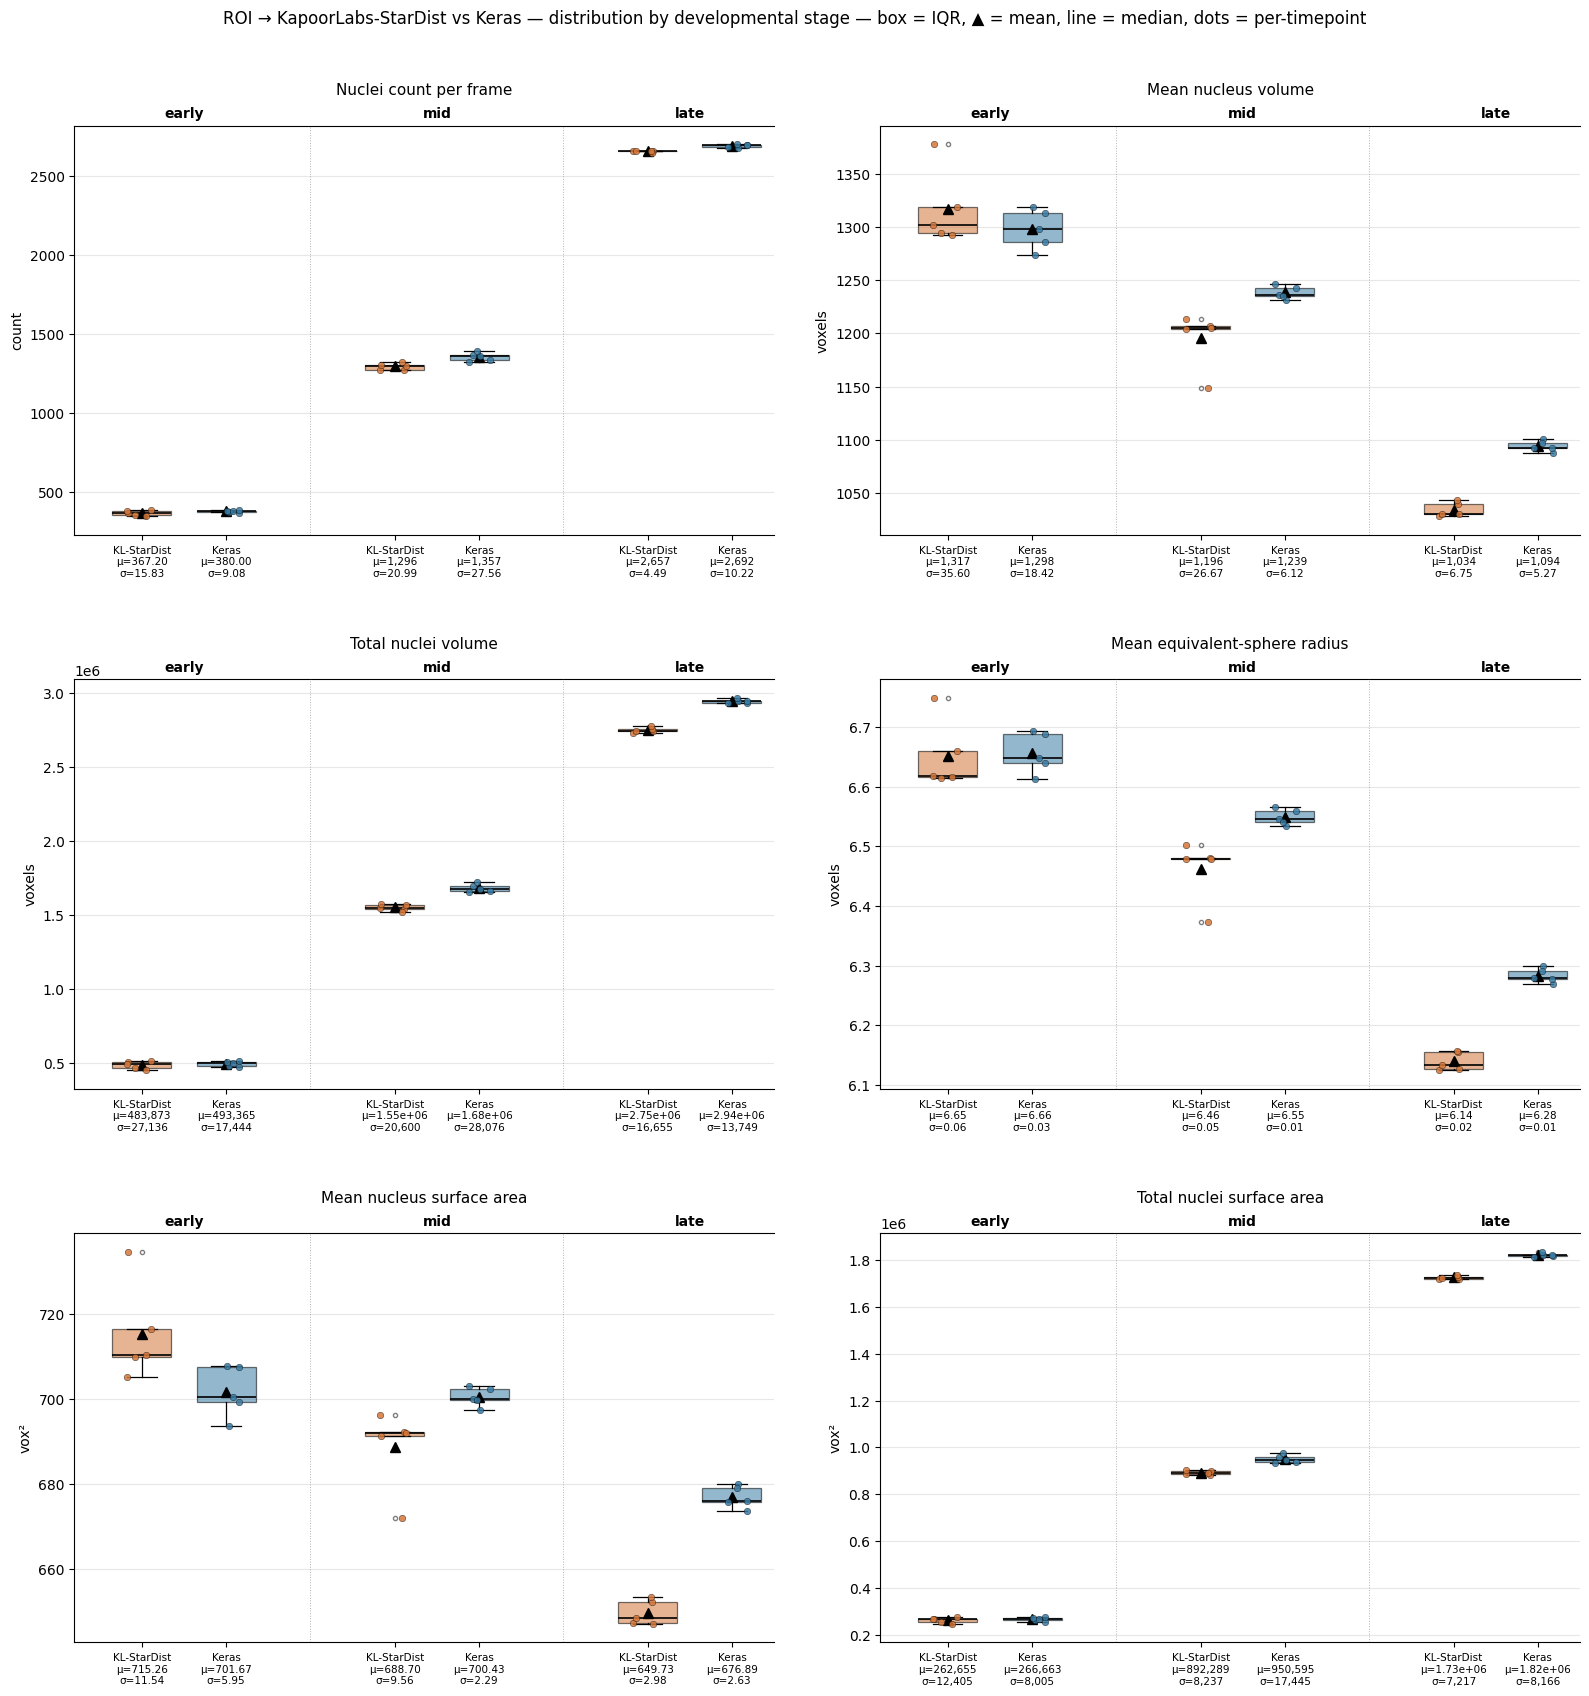

In [12]:
# Box plots per metric, **stratified by developmental stage**.
# The 15 sampled timepoints are split into three equal-size buckets
# (early / mid / late) using the sorted t_index values. Each panel
# shows 6 boxes — 3 stages × 2 sources (KapoorLabs-StarDist orange,
# Keras blue). Whisker convention = 1.5·IQR; triangle = sample mean;
# horizontal line = median; jittered scatter overlay = individual
# timepoints. Mean ± std is baked into each x-tick label so the axes
# stay clean.

plots = [
    ("n_nuclei",           "count",  1.0,              "Nuclei count per frame"),
    ("mean_volume_vox",    "voxels", VOXEL_VOLUME_UM3, "Mean nucleus volume"),
    ("total_volume_vox",   "voxels", VOXEL_VOLUME_UM3, "Total nuclei volume"),
    ("mean_radius_vox",    "voxels", VOXEL_LENGTH_UM,  "Mean equivalent-sphere radius"),
    ("mean_surface_area",  "vox²",   VOXEL_AREA_UM2,   "Mean nucleus surface area"),
    ("total_surface_area", "vox²",   VOXEL_AREA_UM2,   "Total nuclei surface area"),
]


def _stage_buckets(t_indices: list[int], n_stages: int = 3) -> list[list[int]]:
    """Split a sorted list of T-indices into ``n_stages`` equal-size
    buckets. For the default sweep subset (T-indices first/mid/last 5
    of the timelapse) this yields the natural early / mid / late
    grouping. Falls back to fewer stages if there are fewer indices
    than ``n_stages``.
    """
    ts = sorted(t_indices)
    n = len(ts)
    if n_stages <= 0 or n == 0:
        return [ts] if ts else []
    n_stages = min(n_stages, n)
    edges = np.linspace(0, n, n_stages + 1).astype(int)
    return [ts[edges[i]:edges[i + 1]] for i in range(n_stages)]


STAGE_NAMES = ("early", "mid", "late")


def _fmt(v: float) -> str:
    """Compact axis-label formatter — scientific only when needed."""
    av = abs(v)
    if av >= 1e6 or (av < 1e-2 and av != 0):
        return f"{v:.2e}"
    if av >= 1e3:
        return f"{v:,.0f}"
    return f"{v:.2f}"


def _box_per_stage(ax, stages_data, ylabel, title):
    """Per-stage box pairs (KapoorLabs-StarDist vs Keras).

    ``stages_data`` is a list of ``(stage_name, sd_vals, kr_vals)``.
    Each stage gets two adjacent boxes; stages are spaced by 3 units
    with a faint dashed vertical separator between them.
    """
    sd_color = COLOR_STARDIST
    kr_color = COLOR_KERAS
    positions: list[float] = []
    data: list[np.ndarray] = []
    colors: list[str] = []
    stage_centers: list[float] = []
    stage_labels: list[str] = []
    cursor = 1.0
    for stage_name, sd_vals, kr_vals in stages_data:
        positions.extend([cursor, cursor + 1.0])
        data.extend([sd_vals, kr_vals])
        colors.extend([sd_color, kr_color])
        stage_centers.append(cursor + 0.5)
        stage_labels.append(stage_name)
        cursor += 3.0  # 2 boxes + 1 gap

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.7,
        showmeans=True,
        meanprops=dict(marker="^", markerfacecolor="black",
                       markeredgecolor="black", markersize=7),
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(linewidth=0.9),
        whiskerprops=dict(linewidth=0.9, color="black"),
        capprops=dict(linewidth=0.9, color="black"),
        flierprops=dict(marker="o", markersize=3, alpha=0.5),
        patch_artist=True,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor("black")

    # Jittered scatter per box.
    rng = np.random.default_rng(0)
    for pos, vals, c in zip(positions, data, colors):
        if len(vals) == 0:
            continue
        x = pos + rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(x, vals, color=c, edgecolor="black",
                   linewidth=0.3, s=22, alpha=0.85, zorder=3)

    # Faint dashed separators between stages.
    if len(stages_data) > 1:
        for i in range(1, len(stages_data)):
            sep_x = stage_centers[i - 1] + 1.5
            ax.axvline(sep_x, color="grey", linestyle=":",
                       linewidth=0.7, alpha=0.6)

    # Tick labels: source name + μ/σ on multi-line, under each box.
    tick_labels = []
    for (_, sd_vals, kr_vals) in stages_data:
        for name, vals in zip(["KL-StarDist", "Keras"], (sd_vals, kr_vals)):
            if len(vals) == 0:
                tick_labels.append(f"{name}\n(no data)")
            else:
                tick_labels.append(
                    f"{name}\nμ={_fmt(float(np.mean(vals)))}\n"
                    f"σ={_fmt(float(np.std(vals, ddof=1)))}"
                )
    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=7.5)
    ax.tick_params(axis="x", pad=4)

    # Stage labels (early / mid / late) above the panel, centred on
    # each stage's two boxes.
    sec = ax.secondary_xaxis("top")
    sec.set_xticks(stage_centers)
    sec.set_xticklabels(stage_labels, fontsize=10, fontweight="bold")
    sec.tick_params(axis="x", which="both", length=0)

    ax.set_xlim(0.2, cursor - 1.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, pad=22)
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Build the per-stage buckets from the sorted T-indices.
all_ts = sorted(wide["t_index"].tolist())
stage_t_lists = _stage_buckets(all_ts, n_stages=3)
stage_names = STAGE_NAMES[: len(stage_t_lists)]
stage_summary = ", ".join(
    f"{name}={ts}" for name, ts in zip(stage_names, stage_t_lists)
)
print(f"Stage T-indices: {stage_summary}")


fig, axes = plt.subplots(3, 2, figsize=(16, 17))
axes = axes.flatten()
for ax, (metric, unit, scale, title) in zip(axes, plots):
    sd_col = f"{metric}__stardist"
    kr_col = f"{metric}__keras"
    if sd_col not in wide.columns or kr_col not in wide.columns:
        ax.set_axis_off()
        ax.set_title(f"{metric} — missing")
        continue
    stages_data = []
    for name, ts in zip(stage_names, stage_t_lists):
        sub = wide[wide["t_index"].isin(ts)]
        sd_vals = (sub[sd_col].dropna() * scale).to_numpy()
        kr_vals = (sub[kr_col].dropna() * scale).to_numpy()
        stages_data.append((name, sd_vals, kr_vals))
    _box_per_stage(ax, stages_data, ylabel=unit, title=title)

fig.suptitle(
    f"ROI → KapoorLabs-StarDist vs Keras — distribution by developmental stage — "
    f"box = IQR, ▲ = mean, line = median, dots = per-timepoint",
    fontsize=12, y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.98), h_pad=4.2, w_pad=3.0)

OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved {OUT_PNG.resolve()}")

plt.show()

## All timepoints combined

The panel above splits the 15 timepoints into early / mid / late buckets. The combined-across-timepoints view below pools all of them into a single box per source per metric — the original (pre-stratified) format. Useful for a one-glance "are we close to keras overall?" answer; the stratified view above is the one to read when investigating stage-dependent failure modes.

Saved as `compare_roi_stardist_vs_keras.combined.png` so the stage-stratified PNG (`compare_roi_stardist_vs_keras.png`) isn't overwritten — both files end up alongside the notebook.

Saved /mnt/disk/python_workspace/KapoorLabs-VollSeg/scripts/model_prediction/compare_roi_stardist_vs_keras.combined.png


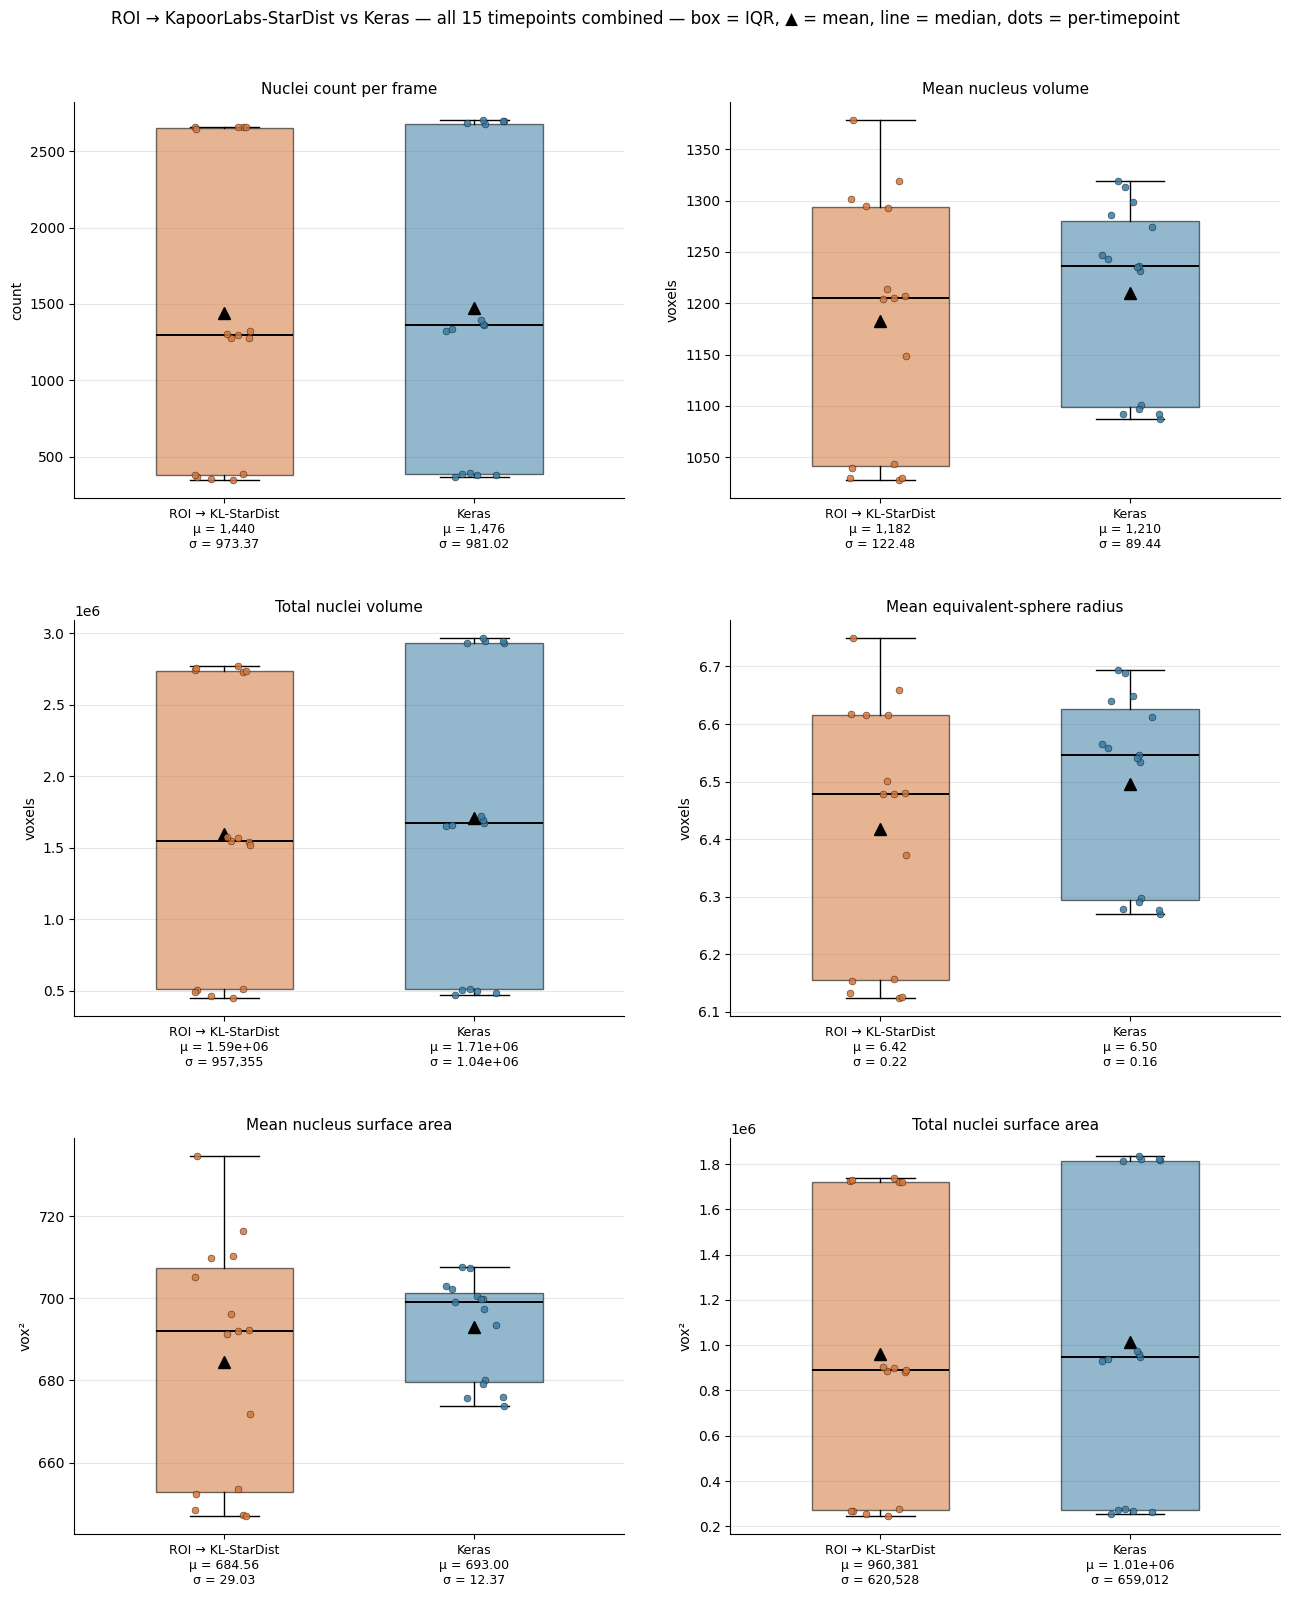

In [13]:
# Combined-timepoints box plot — one box per source per metric,
# every timepoint pooled. Re-uses the same plots / _fmt definitions
# from the stratified cell above.

OUT_PNG_COMBINED = OUT_PNG.with_suffix("").with_suffix(".combined.png")


def _box_pair_combined(ax, sd_vals, kr_vals, ylabel, title):
    """Two-box panel: ROI → KapoorLabs-StarDist (orange) vs Keras (blue),
    pooling all timepoints into a single box per source."""
    data = [sd_vals, kr_vals]
    colors = [COLOR_STARDIST, COLOR_KERAS]
    positions = [1, 2]
    labels = []
    for name, vals in zip(["ROI → KL-StarDist", "Keras"], data):
        if len(vals) == 0:
            labels.append(f"{name}\n(no data)")
        else:
            labels.append(
                f"{name}\nμ = {_fmt(float(np.mean(vals)))}\n"
                f"σ = {_fmt(float(np.std(vals, ddof=1)))}"
            )

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        showmeans=True,
        meanprops=dict(marker="^", markerfacecolor="black",
                       markeredgecolor="black", markersize=8),
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0, color="black"),
        capprops=dict(linewidth=1.0, color="black"),
        flierprops=dict(marker="o", markersize=4, alpha=0.5),
        patch_artist=True,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor("black")

    rng = np.random.default_rng(0)
    for pos, vals, c in zip(positions, data, colors):
        if len(vals) == 0:
            continue
        x = pos + rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(x, vals, color=c, edgecolor="black",
                   linewidth=0.3, s=25, alpha=0.85, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.tick_params(axis="x", pad=4)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(3, 2, figsize=(13, 16))
axes = axes.flatten()
for ax, (metric, unit, scale, title) in zip(axes, plots):
    sd_col = f"{metric}__stardist"
    kr_col = f"{metric}__keras"
    if sd_col not in wide.columns or kr_col not in wide.columns:
        ax.set_axis_off()
        ax.set_title(f"{metric} — missing")
        continue
    sd_vals = (wide[sd_col].dropna() * scale).to_numpy()
    kr_vals = (wide[kr_col].dropna() * scale).to_numpy()
    _box_pair_combined(ax, sd_vals, kr_vals, ylabel=unit, title=title)

fig.suptitle(
    f"ROI → KapoorLabs-StarDist vs Keras — all {len(wide)} timepoints combined — "
    f"box = IQR, ▲ = mean, line = median, dots = per-timepoint",
    fontsize=12, y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.98), h_pad=3.5, w_pad=3.0)

OUT_PNG_COMBINED.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG_COMBINED, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved {OUT_PNG_COMBINED.resolve()}")

plt.show()